# MACHINE LEARNING 2026 - FINAL PROJECT (Option 1)

Course 2025/26: *C. Sun*, *M. Pavan*, *P. Zanuttigh*  

**Group Members:**        
*`Tommaso Dambi ID:2141118`*         
*`Alessandro Costabile ID:2146702`*        
*`Carlo Toffoli ID:2144522`*

## Heart Disease Analysis Using Clustering and Classification
<center>
    <img src="data/dataset-cover.jpg" style = "width: 50%;">
</center>

The dataset labels are the following:

|   id| age   | sex | dataset | cp | trestbps | chol | fbs | restecg | thalch | exang | oldpeak |slope | ca | thal | num |
| :-: | :-:  |  :-: | :-: | :-:| :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| 1  |  63   | Male | Cleveland | typical angina | 145 | 233 | TRUE | Iv hypertrophy | 150 | FALSE | 2.3 | downsloping | 0 | fixed defect | 0 |
| 2  | 67   | Male | Cleveland | asymptomatic | 160 | 286 | FALSE | Iv hypertrophy | 108 | TRUE | 1.5 | flat | 3 | normal | 1 |
| 3   | 67 | Male | Cleveland | asymptomatic | 120 | 229 | FALSE | Iv hypertrophy | 129 | TRUE | 2.6 | flat | 2 | reversable | 2 |
| 4   | 37| Male | Cleveland | non-anginal | 130 | 250 | FALSE | normal | 187 | FALSE | 3.5 | downsloping | 0 | normal | 3 |

Description of the features:
 - `cp`: chest pain type:
    1. typical angina
    2. atypical angina
    3. non-anginal pain
    4. asymptomatic
 - `trestbps`: resting blood pressure (in mm Hg on admission to the hospital)
 - `chol`: serum cholestoral [mg/dL]
 - `fbs`: fasting blood sugar (True if above 120 mg/dL)
 - `restecg`: resting electrocardiographic results
    1. having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    2. showing probable or definite left ventricular hypertrophy by Estes' criteria
    3. normal
 - `thalch`: maximum heart rate achieved
 - `exang`: exercise induced angina
    1. yes
    2. no
 - `oldpeak`: ST depression induced by exercise relative to rest
 - `slope`: the slope of the peak exercise ST segment
    1. upsloping
    2. flat
    3. downsloping
 - `ca`: number of major vessels (0-3) colored by flouroscopy
 - `thal`: type of defect in blood flow towards heart
    1. fixed defect
    2. reversable
    3. normal
 - `num`: label - severity of the disease from 0 (not present) to 4 (max severity)

Some records lack of data of some features such as `trestbps`, `chol`, `fbs`, `thalch`, `exang`, `oldpeak`, `ca`. This has to be addressed, maybe with clustering?

# Documentation used
- [Numpy](https://numpy.org/doc/stable/reference/index.html#reference)
- [Pandas](https://pandas.pydata.org/docs/reference/index.html#api)
- [Scikit-learn](https://scikit-learn.org/stable/api/index.html)

# ⚠️ OCIO
Il dataset non è incluso per ovvi motivi nel repository github. Scaricalo, estrailo e mettilo nella cartella `/data`. Ricorda di aggiornare il nome del file!
Also: the jupyter server was launched from the upper dir of the project (tdc_fp/..). All the relative imports were done accordingly.

# CODE

## Imports

In [342]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tdc_fp.preproc import (
    load_dataset, split_dataset, filter_dataset, 
    encode_dataset, standardize, binarize
)
from seaborn import pairplot, heatmap
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from tdc_fp.supervised import algo_selection
from sklearn.decomposition import PCA
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score

ENC_ORDINAL = True
# ID = 2141118
# np.random.seed(ID)

## 1. Data Preprocessing
All the preprocessing helper functions are defined in `preproc.py`.
As many samples lack the significant `ca` feature we have decided to use just the Cleveland data which provides that feature in almost all the samples.

In [343]:
# Load dataset
# If during testing a column is not needed it may be added to the dropped columns here
csv_dataframe = load_dataset('tdc_fp/data/heart_disease_uci.csv', drop_columns=['id', 'thal'])

encoded_features = [1,2,3,7,11] # TODO: Update when dropping features!
if ENC_ORDINAL:
    # OrdinalEncoder code
    # dataset, value_map = encode_feature(csv_dataframe) # Old code - value map is list of list!
    enc = OrdinalEncoder().fit(csv_dataframe.to_numpy())
    value_map = [np.append(np.random.permutation(a[:-1]), a[-1]) if a[-1] is np.nan else np.random.permutation(a) if i in encoded_features else a for i, a in enumerate(enc.categories_)]
    dataset = OrdinalEncoder(categories=value_map).fit_transform(csv_dataframe.to_numpy())
    feature_names = csv_dataframe.columns
else:
    # OneHotEncoder code
    dataset, feature_names = encode_dataset(csv_dataframe, encoded_features) # OneHotEncoder

# Print the mapped array
print("Dataset is:")
print(dataset.dtype, dataset.shape)

# Deal with nan values BEFORE STANDARDIZATION (issue #2)

# First filter: keep only clean samples from Cleveland
# dataset_filtered = filter_dataset(dataset, lambda x: not np.isnan(x[1]).any() and x[1][2] == np.where(value_map[2] == "Cleveland"))
# dataset_filtered = filter_dataset(dataset.T, lambda x: x[0] not in (12,13)).T
dataset_filtered = filter_dataset(dataset, lambda x: not np.isnan(x[1]).any())
# Second filter: all the samples are from Cleveland, drop that column!
# column 2 is the dataset column
print("\nFiltered dataset is:")
print(dataset_filtered.dtype, dataset_filtered.shape)

X, Y = split_dataset(dataset_filtered)
print("\nX and Y shapes after filtering:")
print(X.shape, Y.shape)

# Comment this code if you're trying to do multiclass classification
Y = binarize(Y)

# A dataframe is useful for visualization
dataframe = pd.DataFrame(X)
dataframe["num"] = Y
dataframe.columns = feature_names

# Standardization
X = standardize(X)

# If you want to take a look to the correlation factor between the single features and the label:
# print(np.corrcoef(X.T[9], Y.ravel()))

print(f"\nUnique values of Y: {np.unique(Y)}")
print()
print(pd.DataFrame(X).describe().round(3))

[array([28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44,
       45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61,
       62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77],
      dtype=object), array(['Female', 'Male'], dtype=object), array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object), array(['asymptomatic', 'atypical angina', 'non-anginal', 'typical angina'],
      dtype=object), array([0.0, 80.0, 92.0, 94.0, 95.0, 96.0, 98.0, 100.0, 101.0, 102.0,
       104.0, 105.0, 106.0, 108.0, 110.0, 112.0, 113.0, 114.0, 115.0,
       116.0, 117.0, 118.0, 120.0, 122.0, 123.0, 124.0, 125.0, 126.0,
       127.0, 128.0, 129.0, 130.0, 132.0, 134.0, 135.0, 136.0, 138.0,
       140.0, 142.0, 144.0, 145.0, 146.0, 148.0, 150.0, 152.0, 154.0,
       155.0, 156.0, 158.0, 160.0, 164.0, 165.0, 170.0, 172.0, 174.0,
       178.0, 180.0, 185.0, 190.0, 192.0, 200.0, nan], dtype=object), array([0.0, 85.0, 100.0, 117.0, 126.0, 129.0

In [336]:
# print(feature_names)

# pairplot(dataframe, hue="num", corner=True)
# plt.savefig("pairplot_onehot.jpg")

# heatmap(data=dataframe.corr(), cmap="crest")
# plt.savefig("heatmap.jpg")

## 2. Clustering analysis

Va capita l'utilità di questa cosa: una volta trovati i cluster cosa ce ne facciamo? Vogliamo classificare in maniera unsupervised? boh
Ok, poi devo farlo prima del PCA? PCA serve solo a visualizzare i dati o posso anche comprendere se una componente in particolare ha la giusta combinazione di features che permette una classificazione lineare?

In [345]:
# Dataset split
permuted_indexes = np.random.permutation(X.shape[0])

X = X[permuted_indexes]
Y = Y[permuted_indexes].ravel()

# Splitting with stratification ensures consistency of the Y distribution between the train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=ID)
print("Distribution of patients in train set:", np.unique(y_train, return_counts=True)[1])
print("Distribution of patients in test set:", np.unique(y_test, return_counts=True)[1])

Distribution of patients in train set: [128 112]
Distribution of patients in test set: [33 28]


Scores - also with inverted labels
Accuracy: 24.92 | 75.08 %
Precision: 27.86 | 72.14 %


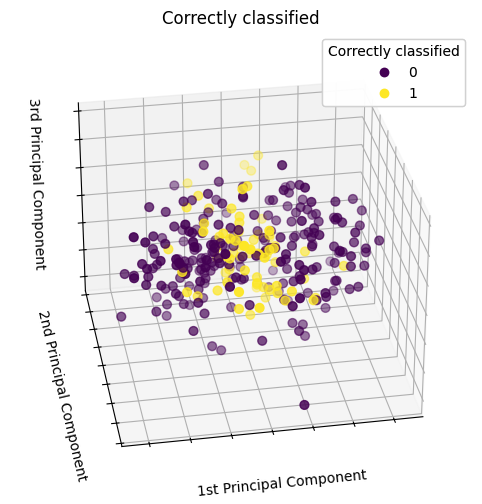

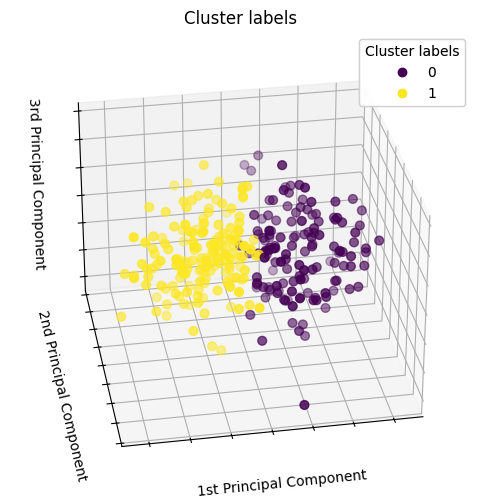

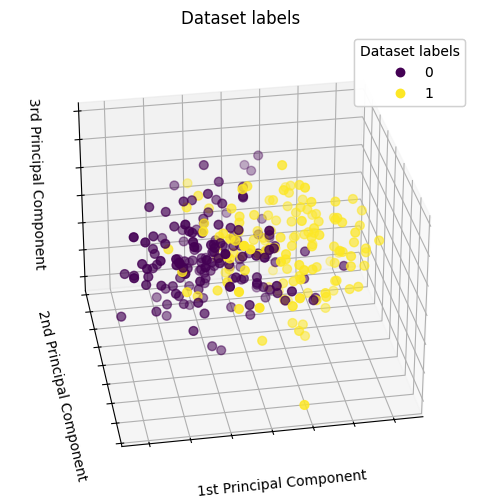

PCA weights:
[-0.34513522  0.12137717 -0.01011665 -0.44093081 -0.04453588 -0.00446884
 -0.08391877  0.17443735  0.08531619  0.46561946 -0.28816233 -0.41862749
 -0.38702188]


In [ ]:
# For what concerns visualization, we need to decompose the data into at most 3 components
# (plus the labels which are represented by the color of the datapoints)

# Do clustering into two clusters
clustering = KMeans(2, n_init=10).fit(X)
# clustering = AgglomerativeClustering(2, linkage='ward').fit(X)

labels = clustering.labels_

print("Scores - also with inverted labels")
print(f"Accuracy: {round(accuracy_score(labels, Y)*100, 2)} | {round((1-accuracy_score(labels, Y))*100, 2)} %")
print(f"Precision: {round(precision_score(labels, Y)*100, 2)} | {round((1-precision_score(labels, Y))*100, 2)} %")
# print(f"Inertia: {clustering.inertia_}")

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X)

plot_clusters(X_reduced, (Y == labels).astype(int), "Correctly classified")
plot_clusters(X_reduced, labels, "Cluster labels")
plot_clusters(X_reduced, Y, "Dataset labels")

print("PCA weights:")
print(pca.components_[0])

## 3. Supervised Learning

In [339]:
# # TODO: Riordinare

# # Call the algorithm selection function
# y_pred, y_score = algo_selection(X_train, X_test, y_train, y_test, ID)
# # The precision is the ratio tp / (tp + fp) where tp is the number of true positives and fp the number of false positives.
# # - Precision: di quelli che ho pedetto malati, quanti lo sono davvero
# # - Recall: dei malati veri, quanti ne ho beccati
# # - F1: media di precision e recall
# print("Test set results: ",
#     "\nAccurancy: ", round(100*np.sum(y_test == y_pred) / len(y_test), 3),
#     "\nPrecision: ", round(100*np.dot(y_test, y_pred) / np.sum(y_pred), 3),
#     "\nRecall: ", round(recall_score(y_test, y_pred), 3))